In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import read
import pickle
from algorithm import Encoding, Matching

morceau_ref = "100.wav"

encoder = Encoding(nperseg=128, noverlap=32, min_distance=25, time_window=1.0, freq_window=1500)

fs, s = read(f'./samples/{morceau_ref}')
signal_extrait = s[0:int(10*fs)]

1)

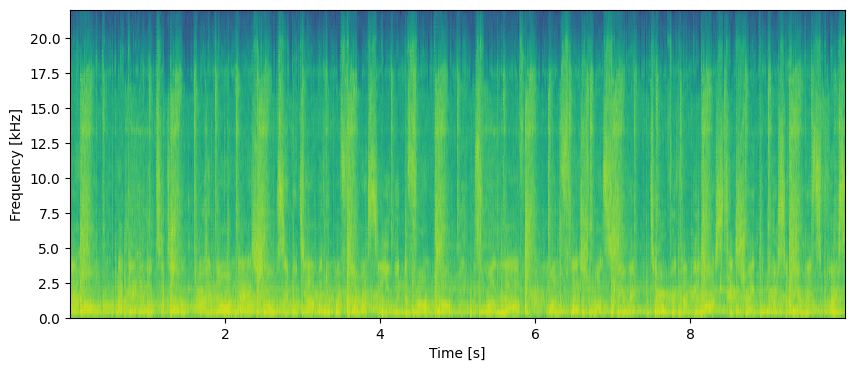

In [9]:
encoder.process(fs, signal_extrait)
plt.figure(figsize=(10, 4))
encoder.display_spectrogram(display_anchors=False)

2)

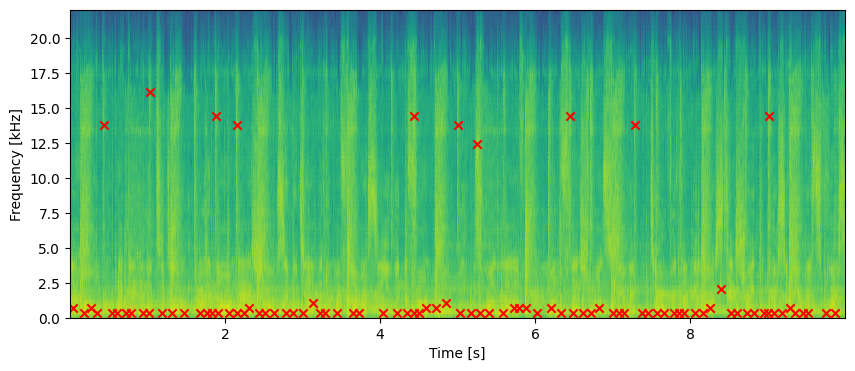

In [10]:
plt.figure(figsize=(10, 4))
encoder.display_spectrogram(display_anchors=True)

3) 
 Oui, la représentation sous forme de code de hachage est invariant par translation parce que ce qui est stockée est uniquement la différence entre les coordonnées temporelles de l'ancre et de la cible et non leur coordonnées temporelles absolues.

5) 

In [14]:
with open('songs.pickle', 'rb') as handle:
    database = pickle.load(handle)

nom_morceau_extrait = '100' 

item = None
for element in database:
    if element['song'] == nom_morceau_extrait:
        item = element
        break
    
autre_item = None
for element in database:
    if element['song'] != nom_morceau_extrait:
        autre_item = element
        break 
print(f"Mauvais morceau : {autre_item['song']}")

Mauvais morceau : 249


Nombre de correspondances : 327


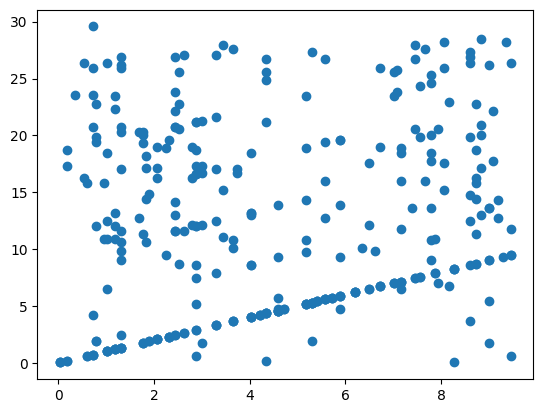

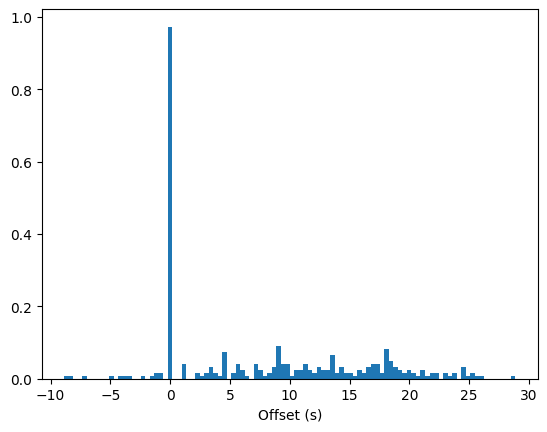

Nombre de correspondances : 354


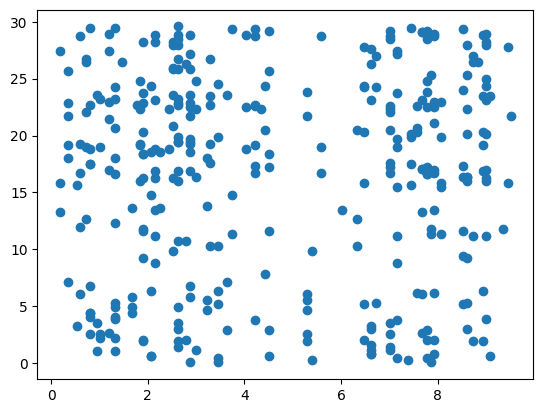

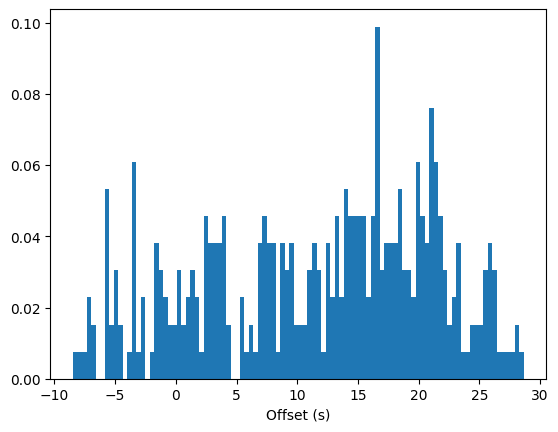

In [16]:
matcher_true = Matching(hashes1=encoder.hashes, hashes2=item['hashcodes'])
print(f"Nombre de correspondances : {len(matcher_true.matching)}")
matcher_true.display_scatterplot()
matcher_true.display_histogram()


matcher_false = Matching(hashes1=encoder.hashes, hashes2=autre_item['hashcodes'])
print(f"Nombre de correspondances : {len(matcher_false.matching)}")
matcher_false.display_scatterplot()
matcher_false.display_histogram()

 Lorsque l'extrait ne correspond pas au morceau, le nuage de points est dépourvu de structure : les points sont réparties de manière aléatoire. À l'inverse, lorsque l'extrait correspond au morceau, une ligne diagonale se dégage nettement malgré le bruit. Cette structure s'explique par l'écoulement identique du temps entre l'extrait et le morceau original ($t_{morceau} = t_{extrait} + \text{décalage}$). L'ordonnée à l'origine de cette droite correspond précisément au décalage temporel de l'extrait.

6) 
self.matching est un tableau de forme (N, 2) où chaque ligne contient [t_ancre_extrait, t_ancre_morceau]. L'offset est donc matching[:, 1] - matching[:, 0], c'est-à-dire le décalage temporel entre l'extrait et le morceau. Quand l'extrait provient du morceau, tous ces offsets sont quasi-identiques (ils valent tstart, le moment où commence l'extrait), ce qui crée un pic net dans l'histogramme.

7)
Le critère est inclus self.max_count et self.is_match. L'idée : quand l'extrait correspond au morceau, l'histogramme des offsets présente un pic très concentré (beaucoup de correspondances avec le même décalage). Pour un mauvais morceau, l'histogramme est plat. Un seuil sur la hauteur du pic permet d'identifier le bon morceau.

9) 

In [ ]:
fs, s = read('./secret_sample.wav')
encoder.process(fs, s)
hashes_mystery = encoder.hashes

best_match = None
best_count = 0

for item in database:
    matcher = Matching(hashes1=hashes_mystery, hashes2=item['hashcodes'])
    if matcher.max_count > best_count:
        best_count = matcher.max_count
        best_match = item['song']

print(f"Le morceau mystère est : {best_match} (score={best_count})")